<a href="https://colab.research.google.com/github/jellybbie/study/blob/save/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('/content/rawdata-spot01fx.xlsx')

In [118]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6
0,Spray TAU-3,85,30,71,44,25,46.0
1,Spray BTH,12,1,2,8,1,3.0
2,Spray MgSO4,82,65,89,73,114,84.6
3,Drench TAU-3,22,50,27,55,25,30.0
4,Drench BTH,15,22,18,15,9,18.0


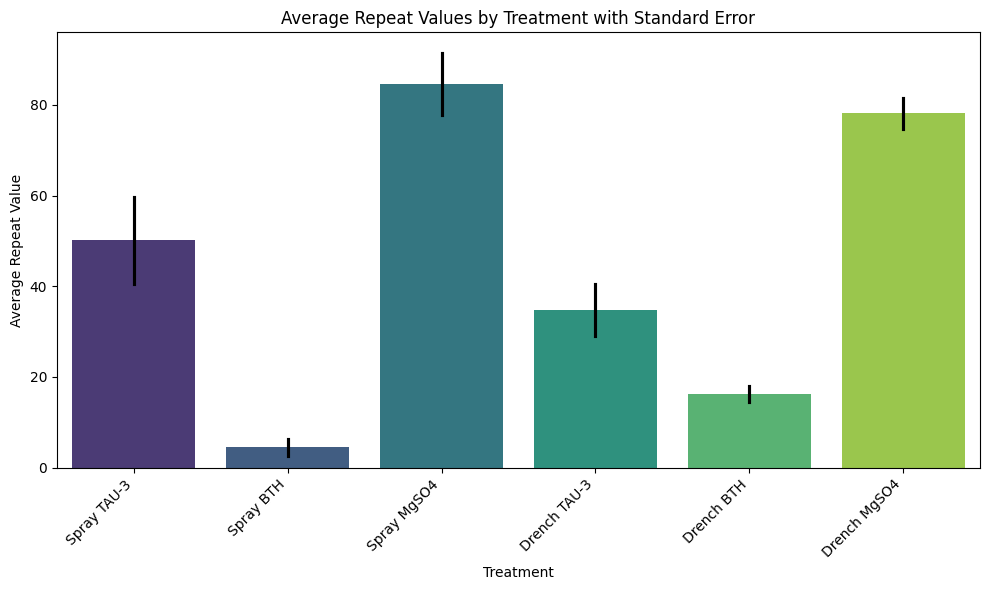

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically select 'repeat' columns
repeat_columns = [col for col in df.columns if col.startswith('repeat')]

# Melt the DataFrame to long format for proper error bar calculation
df_melted = df.melt(id_vars=['Treatment'], value_vars=repeat_columns,
                   var_name='Repeat_Number', value_name='Repeat_Value')

# Create the bar plot with error bars (standard error) and black error bar color
plt.figure(figsize=(10, 6))
sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
            errorbar='se', # Add standard error as error bars
            hue='Treatment', legend=False,
            err_kws={'color': 'black'}) # Set error bar color to black
plt.title('Average Repeat Values by Treatment with Standard Error')
plt.xlabel('Treatment')
plt.ylabel('Average Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [120]:
display(df)

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6
0,Spray TAU-3,85,30,71,44,25,46.0
1,Spray BTH,12,1,2,8,1,3.0
2,Spray MgSO4,82,65,89,73,114,84.6
3,Drench TAU-3,22,50,27,55,25,30.0
4,Drench BTH,15,22,18,15,9,18.0
5,Drench MgSO4,68,80,80,85,68,88.0


In [121]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Perform One-Way ANOVA
# Convert 'Treatment' to categorical type if not already
df_melted['Treatment'] = df_melted['Treatment'].astype('category')

# Create a list of arrays, one for each treatment group
treatment_groups = [df_melted['Repeat_Value'][df_melted['Treatment'] == t] for t in df_melted['Treatment'].unique()]

f_statistic, p_value = stats.f_oneway(*treatment_groups)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    print("\nANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...")
    tukey_results = pairwise_tukeyhsd(endog=df_melted['Repeat_Value'], groups=df_melted['Treatment'], alpha=0.05)
    print(tukey_results)

    # Generate alphabetical labels for groups that are not significantly different
    # Convert Tukey results table to a DataFrame for easier querying
    tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:],
                            columns=tukey_results._results_table.data[0])

    # Create a mapping for reject status between any two groups
    reject_map = {}
    for _, row in tukey_df.iterrows():
        g1, g2, reject = row['group1'], row['group2'], row['reject']
        reject_map[(g1, g2)] = reject
        reject_map[(g2, g1)] = reject # Store symmetrically for easy lookup

    treatments = sorted(df_melted['Treatment'].unique().tolist())
    num_treatments = len(treatments)

    # Initialize labels (use a set to avoid duplicate letters for a single treatment)
    labels = {t: set() for t in treatments}
    current_letter_idx = 0

    # Iterate through treatments to assign letters based on non-significant differences
    for i in range(num_treatments):
        t_i = treatments[i]
        if not labels[t_i]: # If t_i has not been assigned a letter from a previous grouping
            current_char = chr(ord('a') + current_letter_idx)

            # Assign this new letter to t_i
            labels[t_i].add(current_char)

            # Check all other treatments for non-significant difference with t_i
            for j in range(num_treatments):
                t_j = treatments[j]
                if t_i == t_j:
                    continue

                # If t_i and t_j are NOT significantly different, assign the same letter
                # Use .get() with a default of True (rejected) if a pair somehow isn't in the map
                if not reject_map.get((t_i, t_j), True):
                    labels[t_j].add(current_char)

            current_letter_idx += 1

    # Convert sets of letters to sorted strings for final labels (e.g., 'a', 'b', 'ab')
    final_labels = {t: "".join(sorted(list(l))) for t, l in labels.items()}

    # --- START OF LOGIC FOR RANKING LABELS BY MEAN VALUE (A=Highest Mean) ---

    # 1. Calculate the mean for each treatment (ensures it's up-to-date with df_melted)
    current_means = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].mean()

    # 2. Determine distinct label components (e.g., 'a', 'b' from 'a', 'b', 'ab')
    distinct_label_components = sorted(list(set("".join(final_labels.values()))))

    # 3. For each distinct component, find the maximum mean of any treatment associated with it
    component_ranking_means = {}
    for comp in distinct_label_components:
        treatments_with_comp = [t for t, label_str in final_labels.items() if comp in label_str]
        means_for_comp = [current_means[t] for t in treatments_with_comp]
        component_ranking_means[comp] = max(means_for_comp) if means_for_comp else 0

    # 4. Sort these components by their ranking mean in descending order
    sorted_components = sorted(component_ranking_means.items(), key=lambda item: item[1], reverse=True)

    # 5. Assign new capital letters (A, B, C...) based on this rank
    new_letter_map = {}
    for idx, (comp, _) in enumerate(sorted_components):
        new_letter_map[comp] = chr(ord('A') + idx)

    # 6. Apply this mapping to create the final ranked labels for each treatment
    ranked_final_labels = {}
    for treatment, original_label_str in final_labels.items():
        new_label_chars = []
        for char_comp in original_label_str:
            new_label_chars.append(new_letter_map[char_comp])
        # Sort the new label characters to maintain consistency (e.g., 'AB' instead of 'BA')
        ranked_final_labels[treatment] = "".join(sorted(new_label_chars))

    # Update df_melted['Label'] with these new ranked labels
    df_melted['Label'] = df_melted['Treatment'].map(ranked_final_labels)

    print("\nOriginal Alphabetical Labels (Tukey HSD):")
    print(final_labels)
    print("\nRanked Alphabetical Labels (by Mean Value, A=Highest Mean):")
    print(ranked_final_labels)

else:
    print("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.")
    df_melted['Label'] = '' # No labels if not significant

ANOVA F-statistic: 33.35
ANOVA P-value: 0.000

ANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2    meandiff p-adj   lower    upper   reject
------------------------------------------------------------------
  Drench BTH Drench MgSO4     62.0    0.0  37.8197  86.1803   True
  Drench BTH Drench TAU-3  18.6667  0.207  -5.5136  42.8469  False
  Drench BTH    Spray BTH -11.6667 0.6866 -35.8469  12.5136  False
  Drench BTH  Spray MgSO4  68.4333    0.0  44.2531  92.6136   True
  Drench BTH  Spray TAU-3     34.0 0.0022   9.8197  58.1803   True
Drench MgSO4 Drench TAU-3 -43.3333 0.0001 -67.5136 -19.1531   True
Drench MgSO4    Spray BTH -73.6667    0.0 -97.8469 -49.4864   True
Drench MgSO4  Spray MgSO4   6.4333 0.9636 -17.7469  30.6136  False
Drench MgSO4  Spray TAU-3    -28.0 0.0159 -52.1803  -3.8197   True
Drench TAU-3    Spray BTH -30.3333 0.0076 -54.5136  -6.1531   True
Drench TA

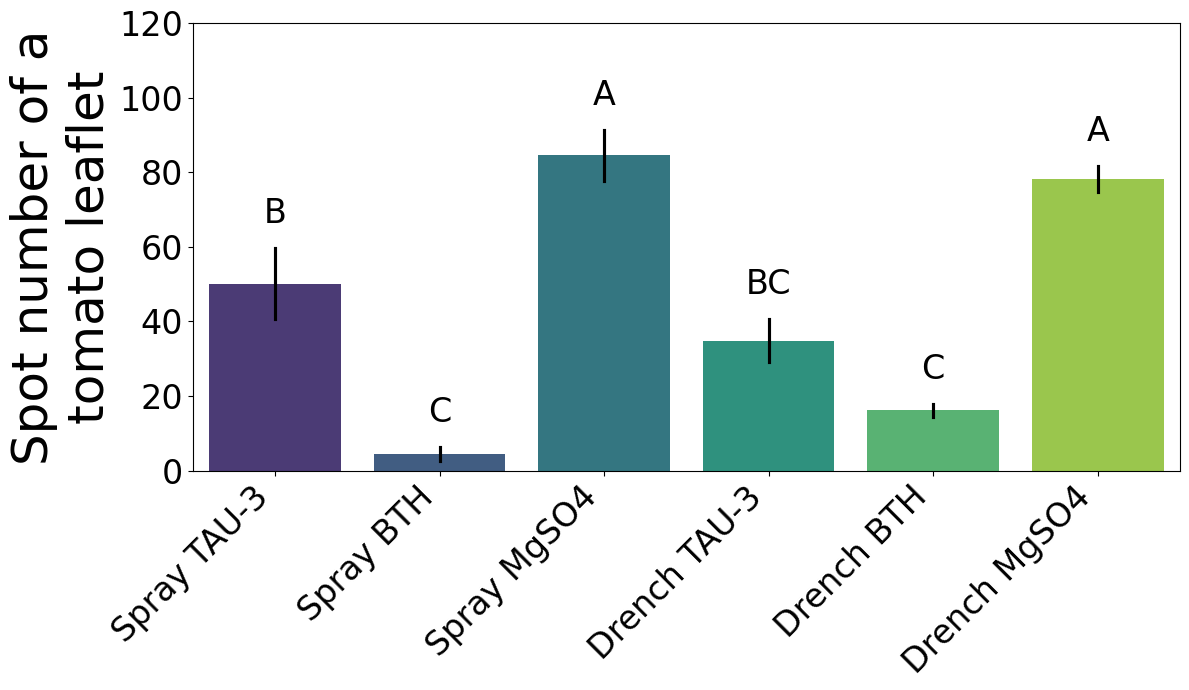

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create the bar plot with alphabetical labels if generated
plt.figure(figsize=(12, 7))

# Define the desired order for the x-axis
custom_treatment_order = ['Spray TAU-3', 'Spray BTH', 'Spray MgSO4', 'Drench TAU-3', 'Drench BTH', 'Drench MgSO4']

ax = sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
            errorbar='se',
            hue='Treatment', legend=False,
            err_kws={'color': 'black'},
            order=custom_treatment_order,
            hue_order=custom_treatment_order) # Ensure hue color assignment follows custom order

# Add alphabetical labels if they exist
if 'Label' in df_melted.columns and not df_melted['Label'].eq('').all():
    # Get the unique treatments and their corresponding labels
    unique_treatments = df_melted[['Treatment', 'Label']].drop_duplicates()
    # Create a dictionary for easier label lookup
    label_mapping = dict(zip(unique_treatments['Treatment'], unique_treatments['Label']))

    # Recalculate means and ses *here* to ensure they are consistent with the plotted data
    current_means = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].mean()
    current_ses = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].sem()

    # Get x-axis tick positions and labels to ensure correct label placement
    x_tick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    x_tick_positions = ax.get_xticks()

    # Create a dictionary to map treatment names to their x-coordinates on the plot
    x_coordinate_map = dict(zip(x_tick_labels, x_tick_positions))

    max_y_for_labels = 0 # Initialize for tracking highest label position

    # Iterate over the custom_treatment_order to ensure labels are placed correctly
    for treatment_name in custom_treatment_order:
        # Get the x-coordinate for this specific treatment from the plot
        x_pos = x_coordinate_map.get(treatment_name)
        if x_pos is None:
            continue # Should not happen if treatment_name is in x_labels

        label = label_mapping.get(treatment_name, '')
        mean_val = current_means.get(treatment_name, 0)
        se_val = current_ses.get(treatment_name, 0)

        # Calculate y_pos above the bar and error bar
        y_pos = mean_val + se_val + (ax.get_ylim()[1] * 0.05) # Use existing ylim for buffer calc

        ax.text(x_pos, y_pos, label,
                ha='center', va='bottom', fontsize=24, weight='normal')

        # Update max_y_for_labels if this label's position is higher
        max_y_for_labels = max(max_y_for_labels, y_pos)

    # Set the y-axis limit to accommodate all labels with a small buffer
    # Using ax.get_ylim()[1] if no labels, otherwise using max_y_for_labels
    current_y_max = ax.get_ylim()[1]
    if max_y_for_labels > current_y_max:
        ax.set_ylim(top=max_y_for_labels * 1.05) # Add 5% buffer above the highest label

# Remove the title
# plt.title('Average Repeat Values by Treatment with Standard Error and Tukey HSD Labels', fontsize=36)
plt.xlabel('') # Removed x-axis label as per user request
plt.ylabel('Spot number of a\ntomato leaflet', fontsize=36) # Changed y-axis label to multiline
plt.xticks(rotation=45, ha='right', fontsize=24) # Font size tripled (assuming 8pt default)
plt.yticks(fontsize=24) # Font size tripled (assuming 8pt default)
ax.set_ylim(top=120) # Set y-axis upper limit to 120
plt.tight_layout()
plt.show()

### Plotting Function for Bar Graph

Below is a function `create_bar_plot` that takes the `df_melted` DataFrame, a list for custom treatment order, and optional y-axis limit and y-axis title parameters. This allows for easy reuse of the plotting logic with different datasets or varying visualization requirements.

In [127]:
def create_bar_plot(df_melted, custom_treatment_order, y_axis_title='Spot number of a\ntomato leaflet', y_axis_limit=None):
    """
    Generates a bar plot with error bars and alphabetical labels.

    Args:
        df_melted (pd.DataFrame): Melted DataFrame containing 'Treatment', 'Repeat_Value', and 'Label' columns.
        custom_treatment_order (list): List of treatment names in the desired display order.
        y_axis_title (str): Title for the y-axis, supports two-line display with '\n'.
        y_axis_limit (int, optional): Upper limit for the y-axis. If None, dynamic scaling is applied.
    """
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
                errorbar='se',
                hue='Treatment', legend=False,
                err_kws={'color': 'black'},
                order=custom_treatment_order,
                hue_order=custom_treatment_order)

    # Add alphabetical labels if they exist
    if 'Label' in df_melted.columns and not df_melted['Label'].eq('').all():
        unique_treatments = df_melted[['Treatment', 'Label']].drop_duplicates()
        label_mapping = dict(zip(unique_treatments['Treatment'], unique_treatments['Label']))

        current_means = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].mean()
        current_ses = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].sem()

        x_tick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
        x_coordinate_map = dict(zip(x_tick_labels, ax.get_xticks()))

        max_y_for_labels = 0

        for treatment_name in custom_treatment_order:
            x_pos = x_coordinate_map.get(treatment_name)
            if x_pos is None:
                continue

            label = label_mapping.get(treatment_name, '')
            mean_val = current_means.get(treatment_name, 0)
            se_val = current_ses.get(treatment_name, 0)

            y_pos = mean_val + se_val + (ax.get_ylim()[1] * 0.05)

            ax.text(x_pos, y_pos, label,
                    ha='center', va='bottom', fontsize=24, weight='normal')

            max_y_for_labels = max(max_y_for_labels, y_pos)

        if y_axis_limit is None:
            current_y_max = ax.get_ylim()[1]
            if max_y_for_labels > current_y_max:
                ax.set_ylim(top=max_y_for_labels * 1.05)

    plt.xlabel('')
    plt.ylabel(y_axis_title, fontsize=36)
    plt.xticks(rotation=45, ha='right', fontsize=24)
    plt.yticks(fontsize=24)
    if y_axis_limit is not None:
        ax.set_ylim(top=y_axis_limit)
    plt.tight_layout()
    plt.show()

### Demonstrate the `create_bar_plot` function

Now, let's use the newly defined function with our `df_melted` data and the desired parameters.

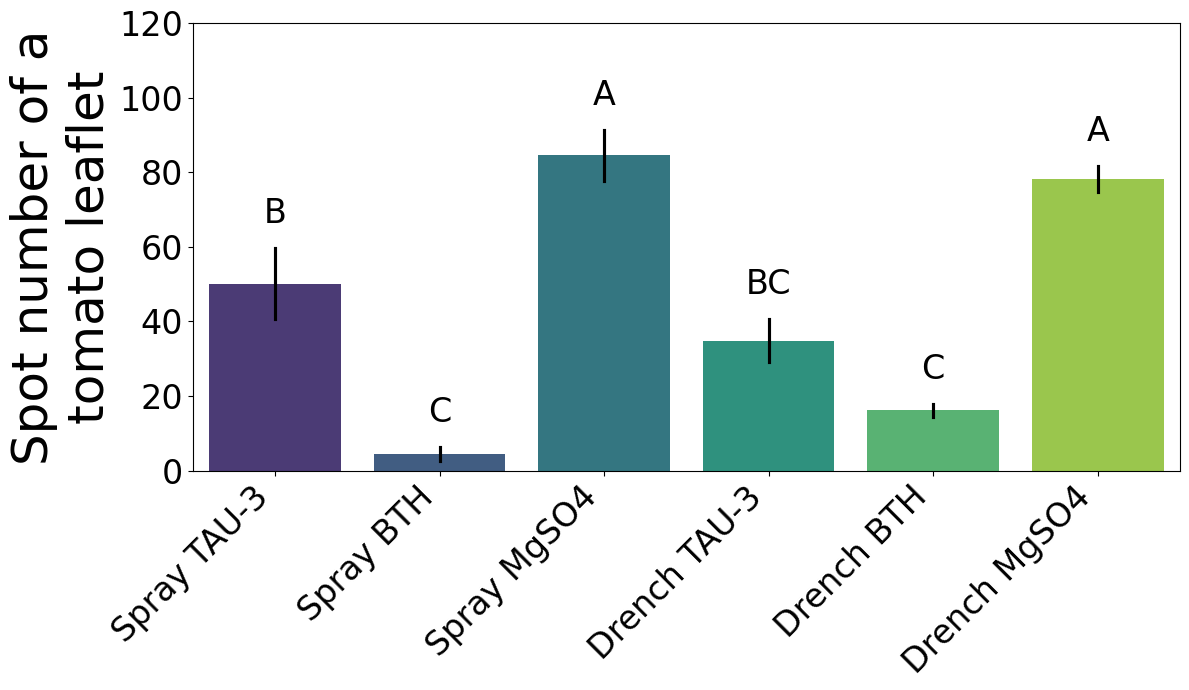

In [128]:
# Define the custom treatment order (as used previously)
custom_treatment_order = ['Spray TAU-3', 'Spray BTH', 'Spray MgSO4', 'Drench TAU-3', 'Drench BTH', 'Drench MgSO4']

# Call the function with your data and desired settings
create_bar_plot(df_melted, custom_treatment_order,
                y_axis_title='Spot number of a\ntomato leaflet', # Two-line title
                y_axis_limit=120) # Fixed y-axis limit

### Apply Plotting Function to `rawdata-spot02.xlsx`

First, let's load the new data from `rawdata-spot02.xlsx`.

In [129]:
# Load the Excel file into a DataFrame for rawdata-spot02.xlsx
df_new = pd.read_excel('/content/rawdata-spot02.xlsx')
display(df_new.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5
0,Spray TAU-3,65,49,57,69,67
1,Spray BTH,6,9,7,10,5
2,Spray MgSO4,59,85,89,54,79
3,Drench TAU-3,46,72,85,80,67
4,Drench BTH,10,24,40,9,3


Next, we need to melt the new DataFrame and perform the statistical analysis (ANOVA and Tukey's HSD) to generate the alphabetical labels, just as we did with the previous dataset.

In [130]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Dynamically select 'repeat' columns for the new DataFrame
repeat_columns_new = [col for col in df_new.columns if col.startswith('repeat')]

# Melt the DataFrame to long format for proper error bar calculation
df_melted_new = df_new.melt(id_vars=['Treatment'], value_vars=repeat_columns_new,
                            var_name='Repeat_Number', value_name='Repeat_Value')

# Convert 'Treatment' to categorical type if not already
df_melted_new['Treatment'] = df_melted_new['Treatment'].astype('category')

# Create a list of arrays, one for each treatment group
treatment_groups_new = [df_melted_new['Repeat_Value'][df_melted_new['Treatment'] == t] for t in df_melted_new['Treatment'].unique()]

f_statistic_new, p_value_new = stats.f_oneway(*treatment_groups_new)

print(f"ANOVA F-statistic: {f_statistic_new:.2f}")
print(f"ANOVA P-value: {p_value_new:.3f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value_new < 0.05:
    print("\nANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...")
    tukey_results_new = pairwise_tukeyhsd(endog=df_melted_new['Repeat_Value'], groups=df_melted_new['Treatment'], alpha=0.05)
    print(tukey_results_new)

    # Generate alphabetical labels for groups that are not significantly different
    # Convert Tukey results table to a DataFrame for easier querying
    tukey_df_new = pd.DataFrame(data=tukey_results_new._results_table.data[1:],
                                columns=tukey_results_new._results_table.data[0])

    # Create a mapping for reject status between any two groups
    reject_map_new = {}
    for _, row in tukey_df_new.iterrows():
        g1, g2, reject = row['group1'], row['group2'], row['reject']
        reject_map_new[(g1, g2)] = reject
        reject_map_new[(g2, g1)] = reject # Store symmetrically for easy lookup

    treatments_new = sorted(df_melted_new['Treatment'].unique().tolist())
    num_treatments_new = len(treatments_new)

    labels_new = {t: set() for t in treatments_new}
    current_letter_idx_new = 0

    for i in range(num_treatments_new):
        t_i = treatments_new[i]
        if not labels_new[t_i]:
            current_char = chr(ord('a') + current_letter_idx_new)
            labels_new[t_i].add(current_char)
            for j in range(num_treatments_new):
                t_j = treatments_new[j]
                if t_i == t_j:
                    continue
                if not reject_map_new.get((t_i, t_j), True):
                    labels_new[t_j].add(current_char)
            current_letter_idx_new += 1

    final_labels_new = {t: "".join(sorted(list(l))) for t, l in labels_new.items()}

    # --- START OF LOGIC FOR RANKING LABELS BY MEAN VALUE (A=Highest Mean) ---
    current_means_new = df_melted_new.groupby('Treatment', observed=False)['Repeat_Value'].mean()
    distinct_label_components_new = sorted(list(set("".join(final_labels_new.values()))))
    component_ranking_means_new = {}
    for comp in distinct_label_components_new:
        treatments_with_comp = [t for t, label_str in final_labels_new.items() if comp in label_str]
        means_for_comp = [current_means_new[t] for t in treatments_with_comp]
        component_ranking_means_new[comp] = max(means_for_comp) if means_for_comp else 0
    sorted_components_new = sorted(component_ranking_means_new.items(), key=lambda item: item[1], reverse=True)
    new_letter_map_new = {}
    for idx, (comp, _) in enumerate(sorted_components_new):
        new_letter_map_new[comp] = chr(ord('A') + idx)
    ranked_final_labels_new = {}
    for treatment, original_label_str in final_labels_new.items():
        new_label_chars = []
        for char_comp in original_label_str:
            new_label_chars.append(new_letter_map_new[char_comp])
        ranked_final_labels_new[treatment] = "".join(sorted(new_label_chars))

    df_melted_new['Label'] = df_melted_new['Treatment'].map(ranked_final_labels_new)

    print("\nOriginal Alphabetical Labels (Tukey HSD):")
    print(final_labels_new)
    print("\nRanked Alphabetical Labels (by Mean Value, A=Highest Mean):")
    print(ranked_final_labels_new)

else:
    print("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.")
    df_melted_new['Label'] = '' # No labels if not significant

ANOVA F-statistic: 30.97
ANOVA P-value: 0.000

ANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2    meandiff p-adj    lower    upper   reject
-------------------------------------------------------------------
  Drench BTH Drench MgSO4     82.6    0.0   54.7131 110.4869   True
  Drench BTH Drench TAU-3     52.8 0.0001   24.9131  80.6869   True
  Drench BTH    Spray BTH     -9.8 0.8819  -37.6869  18.0869  False
  Drench BTH  Spray MgSO4     56.0    0.0   28.1131  83.8869   True
  Drench BTH  Spray TAU-3     44.2 0.0007   16.3131  72.0869   True
Drench MgSO4 Drench TAU-3    -29.8 0.0314  -57.6869  -1.9131   True
Drench MgSO4    Spray BTH    -92.4    0.0 -120.2869 -64.5131   True
Drench MgSO4  Spray MgSO4    -26.6 0.0677  -54.4869   1.2869  False
Drench MgSO4  Spray TAU-3    -38.4 0.0033  -66.2869 -10.5131   True
Drench TAU-3    Spray BTH    -62.6    0.0  -90.4869 -34.7131   T

Finally, we can call the `create_bar_plot` function with the `df_melted_new` and appropriate parameters for the new data.

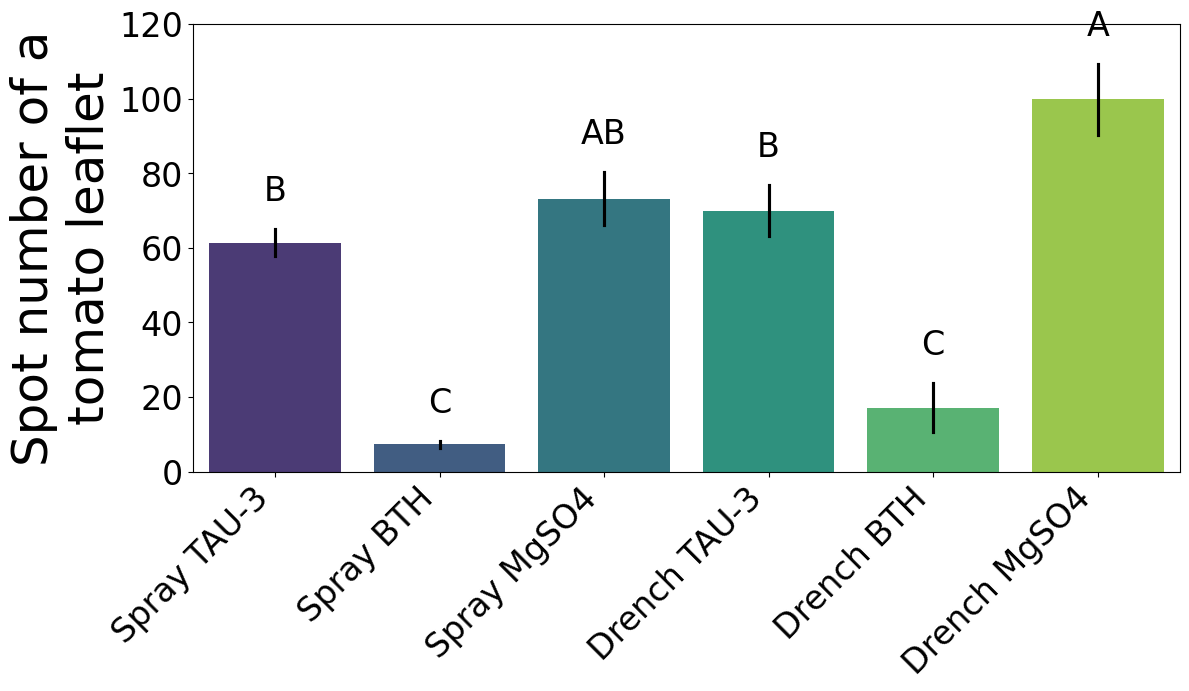

In [132]:
# Define the custom treatment order for the new data (adjust if needed for rawdata-spot02.xlsx)
# Assuming the same order or an appropriate default if not specified by user for this new file.
custom_treatment_order_new = ['Spray TAU-3', 'Spray BTH', 'Spray MgSO4', 'Drench TAU-3', 'Drench BTH', 'Drench MgSO4']

# Call the function with the new data and desired settings
create_bar_plot(df_melted_new, custom_treatment_order_new,
                y_axis_title='Spot number of a\ntomato leaflet', # Can be customized
                y_axis_limit=120) # Can be customized